# Cosmological Emulator with BaccoEmu

This notebook demonstrates how to compute the **matter power spectrum** using the **BaccoEmu** cosmological emulator via the `pyccl` Python library. 

Key steps include:

- **Setup**: Import `pyccl`, `numpy`, `matplotlib` and configure plotting.
- **BaccoEmu Initialization**: Load linear, non-linear, no-wiggles, sigma8, and baryonic emulators.
- **Wavenumber Ranges**: Examine the `k` ranges for linear and non-linear emulators.
- **Linear & Non-linear Power Spectra**: Compute and plot the linear and non-linear matter power spectra.
- **Baryonic Corrections**: Apply baryonic effects to the non-linear power spectrum and visualize their impact.
- **Parameter Updates**: Adjust baryonic parameters with `baryons.update_parameters()`.

**Source**: [CCLX Cosmological Emulator Notebook](https://github.com/LSSTDESC/CCLX/blob/master/Cosmological_Emulator.ipynb)  
**Author / Maintainer**: LSST Dark Energy Science Collaboration (DESC)  

This notebook provides a practical workflow for using **BaccoEmu** to study matter clustering in the universe, including baryonic effects on small scales.  

- # `Import libraries and configure`

In [1]:
# Import necessary libraries
import pyccl as ccl
import numpy as np
import matplotlib.pyplot as plt

# Configure Jupyter display settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

- # `Plot and NumPy configuration`

In [2]:
# Configure plot and NumPy display settings
plt.rcParams['figure.figsize'] = (6.5, 5.5)  # Set default figure size
np.set_printoptions(linewidth=120)            # Set NumPy print width for cleaner array output
np.get_printoptions()                         # Display current NumPy print settings

{'edgeitems': 3,
 'threshold': 1000,
 'floatmode': 'maxprec',
 'precision': 8,
 'suppress': False,
 'linewidth': 120,
 'nanstr': 'nan',
 'infstr': 'inf',
 'sign': '-',
 'formatter': None,
 'legacy': False}

- # `Baccoemu matter power initialization`

In [4]:
# Import baccoemu and initialize the matter power spectrum emulator
import baccoemu

# Initialize the emulator
emulator = baccoemu.Matter_powerspectrum()

# Extract the wavenumber ranges for linear and nonlinear spectra
k_range_lin = emulator.emulator['linear']['k']       # linear P(k) k-values
k_range_nl = emulator.emulator['nonlinear']['k']    # nonlinear P(k) k-values

# Optional: check the k-ranges
print("Linear k-range:", k_range_lin[:5], "...", k_range_lin[-5:])
print("Nonlinear k-range:", k_range_nl[:5], "...", k_range_nl[-5:])

Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...


Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Linear k-range: [0.0001     0.00010221 0.00010448 0.00010679 0.00010916] ... [45.80505863 46.81958756 47.85658713 48.91655503 50.        ]
Nonlinear k-range: [0.01019735 0.01060381 0.01102647 0.01146598 0.01192301] ... [4.19357199 4.36072558 4.53454183 4.7152863  4.90323515]


- # `k-range min/max print`

In [5]:
# Print the min and max values of the k-ranges
print("linear:", "min:", min(k_range_lin), "[h/Mpc]", "max:", max(k_range_lin), "[h/Mpc]")
print("non-linear:", "min:", min(k_range_nl), "[h/Mpc]", "max:", max(k_range_nl), "[h/Mpc]")

linear: min: 0.0001 [h/Mpc] max: 49.99999999999999 [h/Mpc]
non-linear: min: 0.010197349385252722 [h/Mpc] max: 4.903235148249275 [h/Mpc]


- # `Baccoemu k-array setup`

In [6]:
# Define wavenumber range for baccoemu (nonlinear) and scale factor
kmin, kmax, nk = min(k_range_nl), max(k_range_nl), 128

# Wavenumber array in [Mpc]^-1 (convert from h/Mpc using h=0.67)
k_bemu = np.logspace(np.log10(kmin * 0.67), np.log10(kmax * 0.67), nk)

# Scale factor at z = 0
a = 1.0

# Optional: check
print("k_bemu range:", k_bemu[0], "to", k_bemu[-1], "[Mpc^-1]")
print("Scale factor a =", a)

k_bemu range: 0.006832224088119325 to 3.285167549327014 [Mpc^-1]
Scale factor a = 1.0


- #  `Linear Baccoemu matter spectrum`

In [7]:
# Initialize the linear Baccoemu matter power spectrum
bemu_lin = ccl.BaccoemuLinear()

# Define a cosmology in CCL using this linear emulator
cosmo_lin = ccl.Cosmology(
    Omega_c=0.27,          # Cold dark matter density
    Omega_b=0.05,          # Baryon density
    h=0.67,                # Hubble parameter
    n_s=0.96,              # Scalar spectral index
    sigma8=0.83,           # RMS of density fluctuations
    m_nu=0.1,              # Neutrino mass
    transfer_function='boltzmann_camb',
    matter_power_spectrum=bemu_lin  # Use Baccoemu linear emulator
)

# Optional: check the linear power spectrum at z=0
k_test = np.logspace(-3, 1, 50)  # [Mpc^-1]
pk_lin = ccl.linear_matter_power(cosmo_lin, k_test, a)
print("Linear P(k) at z=0:", pk_lin[:5], "...", pk_lin[-5:])

Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Linear P(k) at z=0: [19115.0580831  22599.04874661 26613.18313914 31189.90561952 36342.02659702] ... [1.92579815 1.18238148 0.72365967 0.4416074  0.26868949]


- # `Nonlinear Baccoemu matter spectrum`

In [8]:
# Initialize the nonlinear Baccoemu matter power spectrum
bemu_nl = ccl.BaccoemuNonlinear()

# Define a cosmology in CCL using this nonlinear emulator
cosmo_nl = ccl.Cosmology(
    Omega_c=0.27,          # Cold dark matter density
    Omega_b=0.05,          # Baryon density
    h=0.67,                # Hubble parameter
    n_s=0.96,              # Scalar spectral index
    sigma8=0.83,           # RMS of density fluctuations
    m_nu=0.1,              # Neutrino mass
    transfer_function='boltzmann_camb',
    matter_power_spectrum=bemu_nl  # Use Baccoemu nonlinear emulator
)

# Optional: check the nonlinear power spectrum at z=0
k_test = np.logspace(-3, 1, 50)  # [Mpc^-1]
pk_nl = ccl.nonlin_matter_power(cosmo_nl, k_test, a)
print("Non-linear P(k) at z=0:", pk_nl[:5], "...", pk_nl[-5:])

Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Non-linear P(k) at z=0: [37374.78778168 40030.27509753 42874.43540132 45920.67395249 49183.34845724] ... [73.05508882 52.109644   37.16941614 26.51266427 18.91128351]


- # `Plot linear nonlinear Pk`

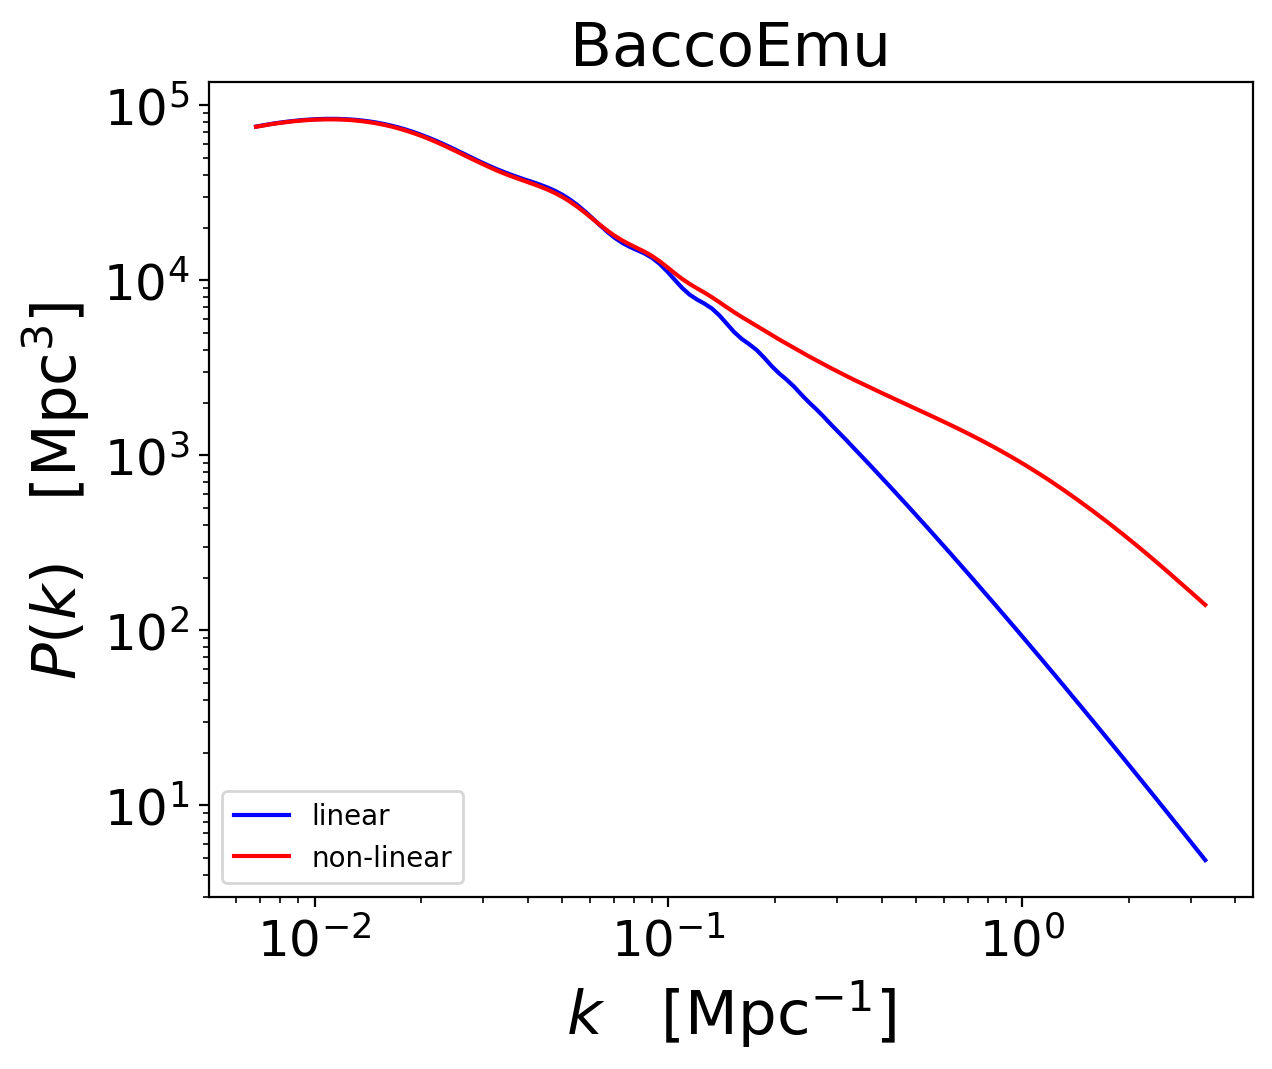

In [10]:
# Get callable linear and nonlinear power spectra from CCL cosmologies
pk_lin_bemu = cosmo_lin.get_linear_power()
pk_nl_bemu = cosmo_nl.get_nonlin_power()

# Plot linear and nonlinear P(k)
plt.plot(k_bemu, pk_lin_bemu(k_bemu, a), 'b-', label="linear")
plt.plot(k_bemu, pk_nl_bemu(k_bemu, a), 'r-', label="non-linear")

# Set log scales
plt.xscale('log')
plt.yscale('log')

# Formatting
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(loc='lower left', fontsize=10)

# Use raw strings (r"") to avoid invalid escape sequences
plt.xlabel(r'$k\quad[\rm Mpc^{-1}]$', fontsize=22)
plt.ylabel(r'$P(k)\quad[\rm Mpc^3]$', fontsize=22)
plt.title("BaccoEmu", fontsize=22)

plt.tight_layout()
plt.show()

- # `Baccoemu baryon-corrected spectrum`

In [12]:
# Initialize the Baccoemu baryons module
baryons = ccl.BaccoemuBaryons()

# Get the original nonlinear matter power spectrum
pk2d_gro = cosmo_nl.get_nonlin_power()

# Include baryonic effects
pk2d_bcm = baryons.include_baryonic_effects(cosmo_nl, pk2d_gro)

# Optional: check a few values
print("Original nonlinear P(k) at z=0:", pk2d_gro(k_bemu, a)[:5], "...")
print("Baryon-corrected P(k) at z=0:", pk2d_bcm(k_bemu, a)[:5], "...")

Original nonlinear P(k) at z=0: [75393.90221612 76721.37794709 77968.20929626 79113.69014855 80111.31891736] ...
Baryon-corrected P(k) at z=0: [75393.90221612 76724.67533258 77979.3419061  79108.73258485 80106.77987577] ...


- # `Baryon suppression ratio plot`

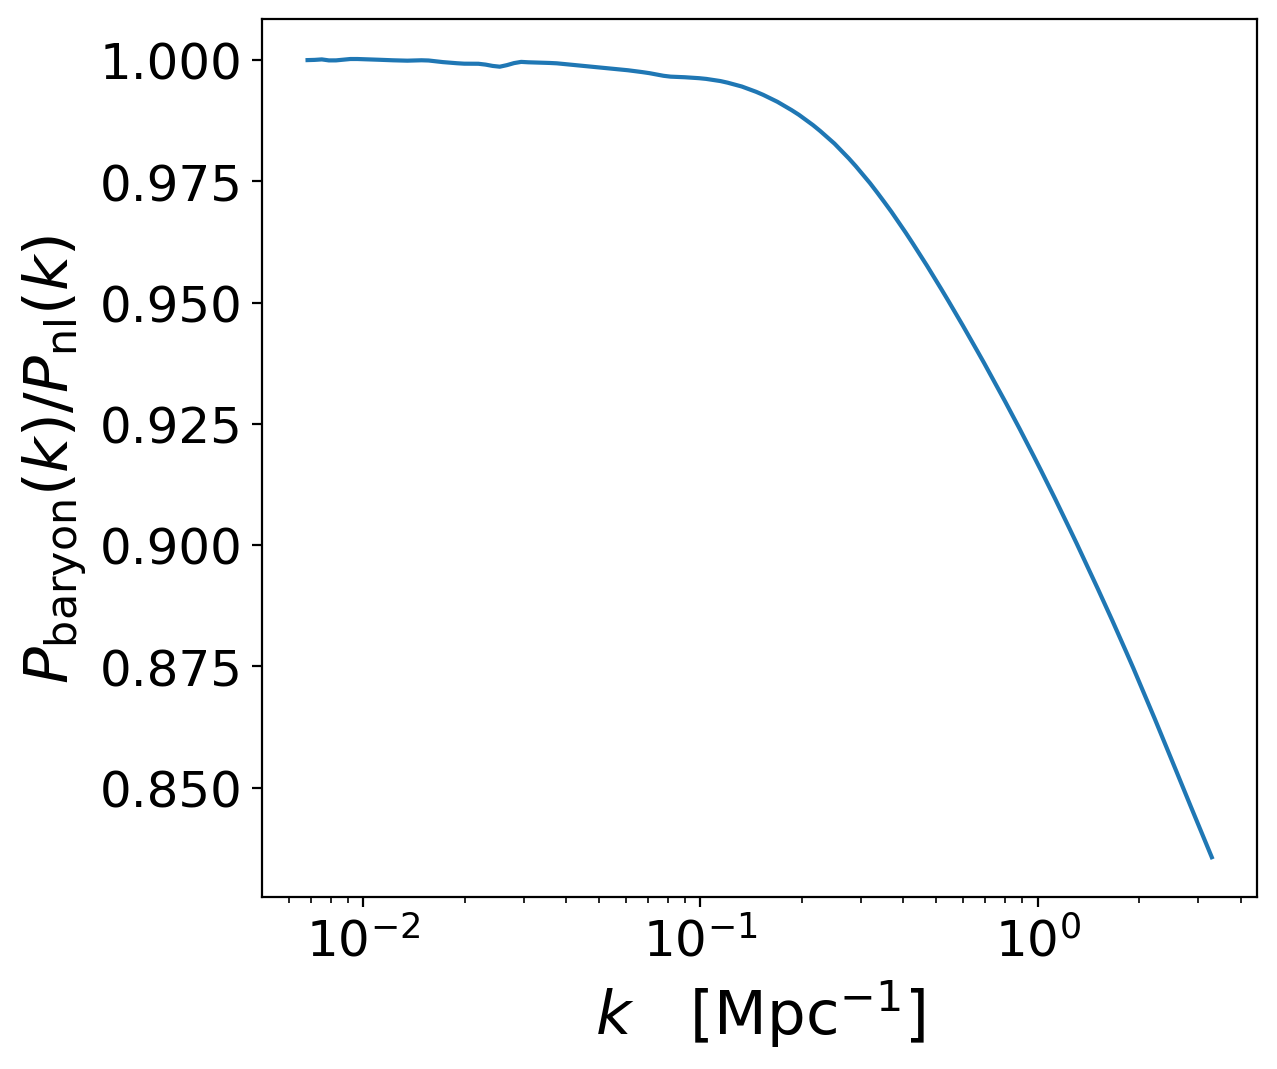

In [13]:
# Plot baryon suppression ratio
plt.plot(k_bemu, pk2d_bcm(k_bemu, a) / pk2d_gro(k_bemu, a))

# Log scale and formatting
plt.xscale('log')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Use raw strings for LaTeX labels
plt.xlabel(r'$k\quad[\rm Mpc^{-1}]$', fontsize=22)
plt.ylabel(r'$P_{\rm baryon}(k)/P_{\rm nl}(k)$', fontsize=22)

plt.tight_layout()
plt.show()

- # `Update baryon model parameter`

In [16]:
# Update baryonic correction model parameter
baryons.update_parameters(log10_M_c=12.7)